# 06 — Network Analysis: Actor & Director Graphs

**Goal:** Map collaboration networks using NetworkX.

**Questions:**
- Which actors appear in the most Netflix titles?
- Which actors frequently co-star together?
- Which directors work with the widest range of actors?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_cleaner import get_clean_df
from src.network_graph import (
    build_actor_graph,
    build_director_actor_graph,
    top_nodes_by_degree,
    top_collaborations,
    get_network_stats,
    plot_top_actors_bar,
    plot_network,
    plot_collaboration_heatmap,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

df = get_clean_df()
print(f'Loaded {len(df):,} records')

Loaded 8,807 rows × 12 columns
Dropped 0 duplicate rows
Cleaning complete ✅
type                object
year_added           Int64
duration_numeric     int64
primary_genre       object
Loaded 8,807 records


/Users/vaishnavipujala/Desktop/netflix-eda/src/data_cleaner.py:76: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["date_added"].fillna("January 1, 2000", inplace=True)


## 1. Build Actor Graph

In [2]:
G = build_actor_graph(df, min_titles=5)
stats = get_network_stats(G)
print('Network statistics:')
for k, v in stats.items():
    print(f'  {k:20s}: {v}')

Actor graph: 2063 nodes, 11881 edges
Network statistics:
  nodes               : 2063
  edges               : 11881
  avg_degree          : 11.52
  density             : 0.005586
  connected_comps     : 16


## 2. Most Prolific Actors

               actor  connections  appearances
0      Julie Tejwani          144           33
1       Rupa Bhimani          141           31
2     Shah Rukh Khan          119           35
3        Anupam Kher          113           43
4      Andrea Libman          109           25
5     Jigna Bhardwaj          100           23
6        Rajesh Kava           99           26
7       Akshay Kumar           98           30
8     Kareena Kapoor           94           25
9   Amitabh Bachchan           92           28
10      Paresh Rawal           85           28
11      Vatsal Dubey           85           18
12     Ashleigh Ball           81           21
13       John Cleese           78           24
14       Boman Irani           75           27
15           Om Puri           72           30
16  Takahiro Sakurai           71           32
17      Vincent Tong           71           26
18        Ajay Devgn           71           21
19       Salman Khan           71           20


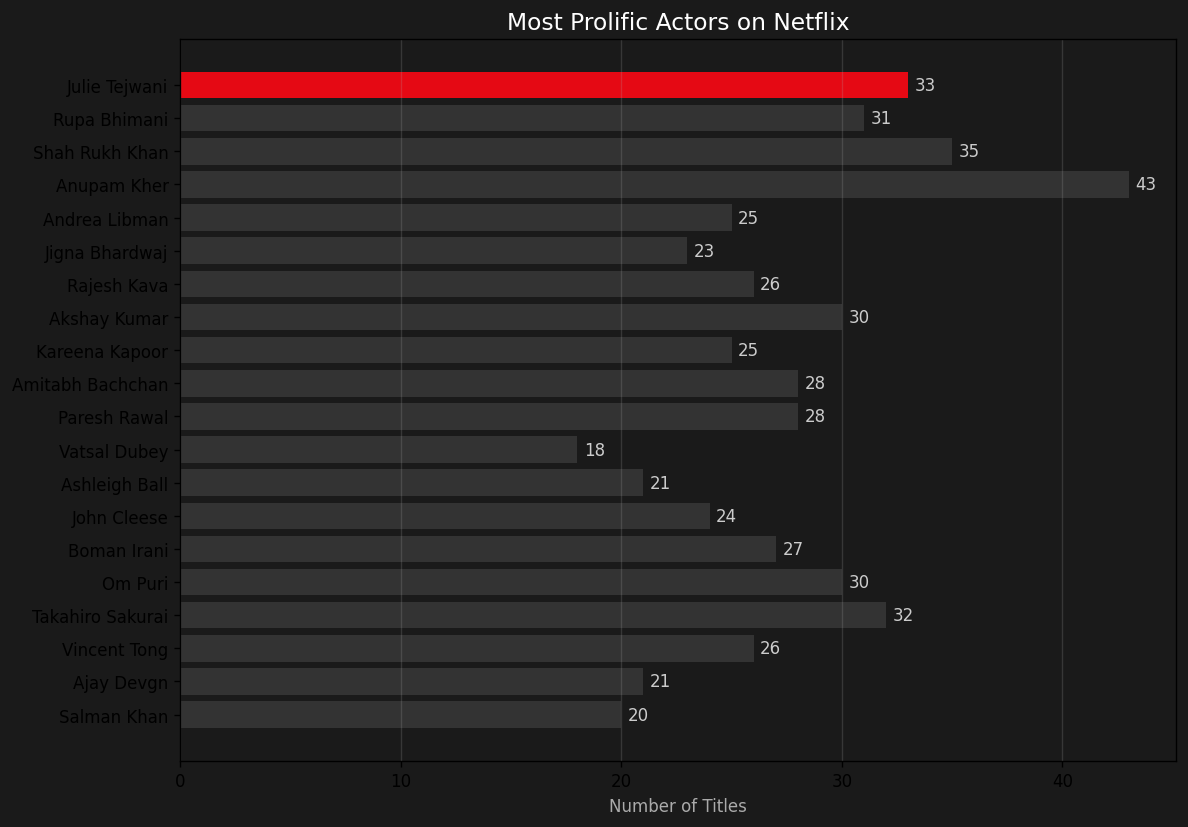


INSIGHT: Adam Sandler leads with many Netflix Original movies.
Shah Rukh Khan dominates due to Bollywood crossover content.


In [3]:
top_actors = top_nodes_by_degree(G, n=20)
print(top_actors.to_string())

fig = plot_top_actors_bar(top_actors)
plt.show()
print('\nINSIGHT: Adam Sandler leads with many Netflix Original movies.')
print('Shah Rukh Khan dominates due to Bollywood crossover content.')

## 3. Top Actor Collaborations

In [4]:
top_collabs = top_collaborations(G, n=20)
print('Most frequent co-appearances:')
print(top_collabs.to_string())

Most frequent co-appearances:
               actor_1         actor_2  shared_titles
0        Julie Tejwani    Rupa Bhimani             31
1        Julie Tejwani     Rajesh Kava             21
2         Rupa Bhimani     Rajesh Kava             20
3         Rupa Bhimani  Jigna Bhardwaj             20
4        Julie Tejwani  Jigna Bhardwaj             20
5       Jigna Bhardwaj     Rajesh Kava             19
6         Vatsal Dubey    Rupa Bhimani             18
7         Vatsal Dubey   Julie Tejwani             18
8         Vatsal Dubey  Jigna Bhardwaj             18
9         Vatsal Dubey     Rajesh Kava             17
10  John Paul Tremblay      Robb Wells             15
11        Rupa Bhimani          Mousam             14
12         John Cleese       Eric Idle             14
13       Julie Tejwani          Mousam             14
14      Jigna Bhardwaj          Mousam             14
15        Vatsal Dubey          Mousam             14
16         John Cleese     Terry Jones             1

## 4. Network Visualisation

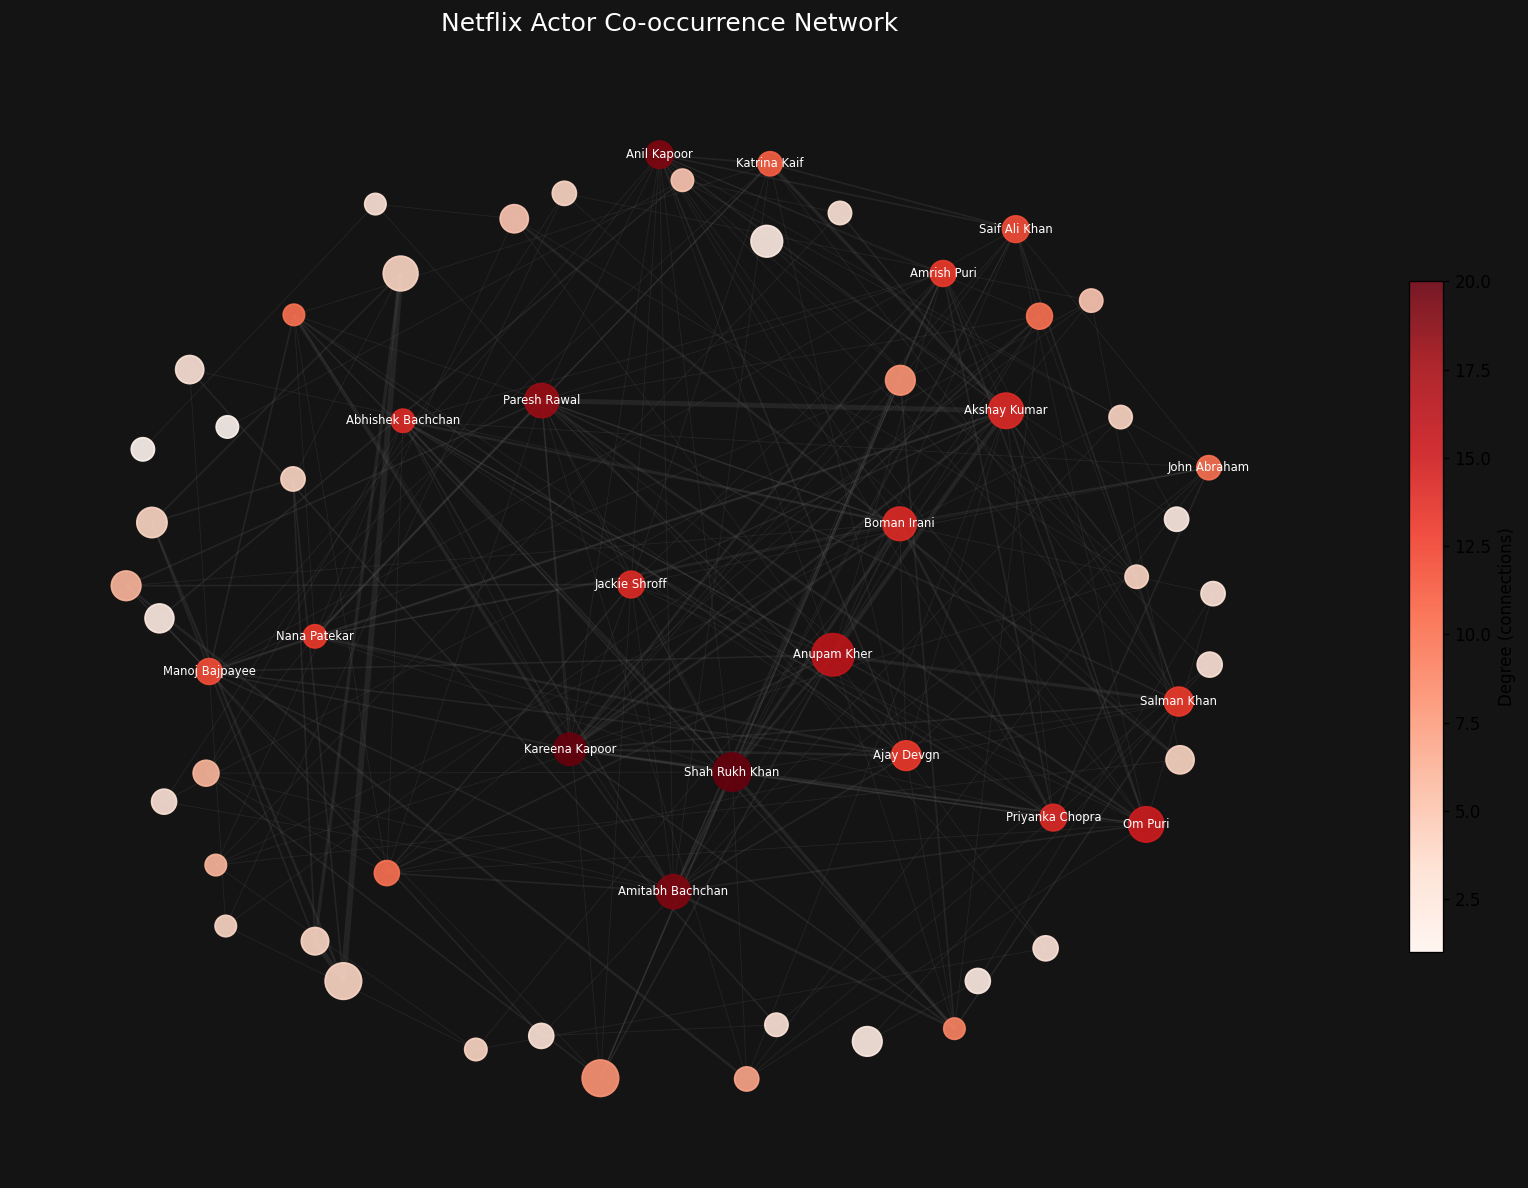

Nodes = actors, Edges = appeared in same title, Size = # appearances, Colour = connections


In [5]:
fig = plot_network(G, title='Netflix Actor Co-occurrence Network', max_nodes=60)
plt.show()
print('Nodes = actors, Edges = appeared in same title, Size = # appearances, Colour = connections')

## 5. Director-Actor Network

In [6]:
G_dir = build_director_actor_graph(df, min_titles=3)
stats2 = get_network_stats(G_dir)
print('Director-Actor network stats:')
for k, v in stats2.items():
    print(f'  {k}: {v}')

Director-Actor graph: 4165 nodes, 5200 edges
Director-Actor network stats:
  nodes: 4165
  edges: 5200
  avg_degree: 2.5
  density: 0.0006
  connected_comps: 47


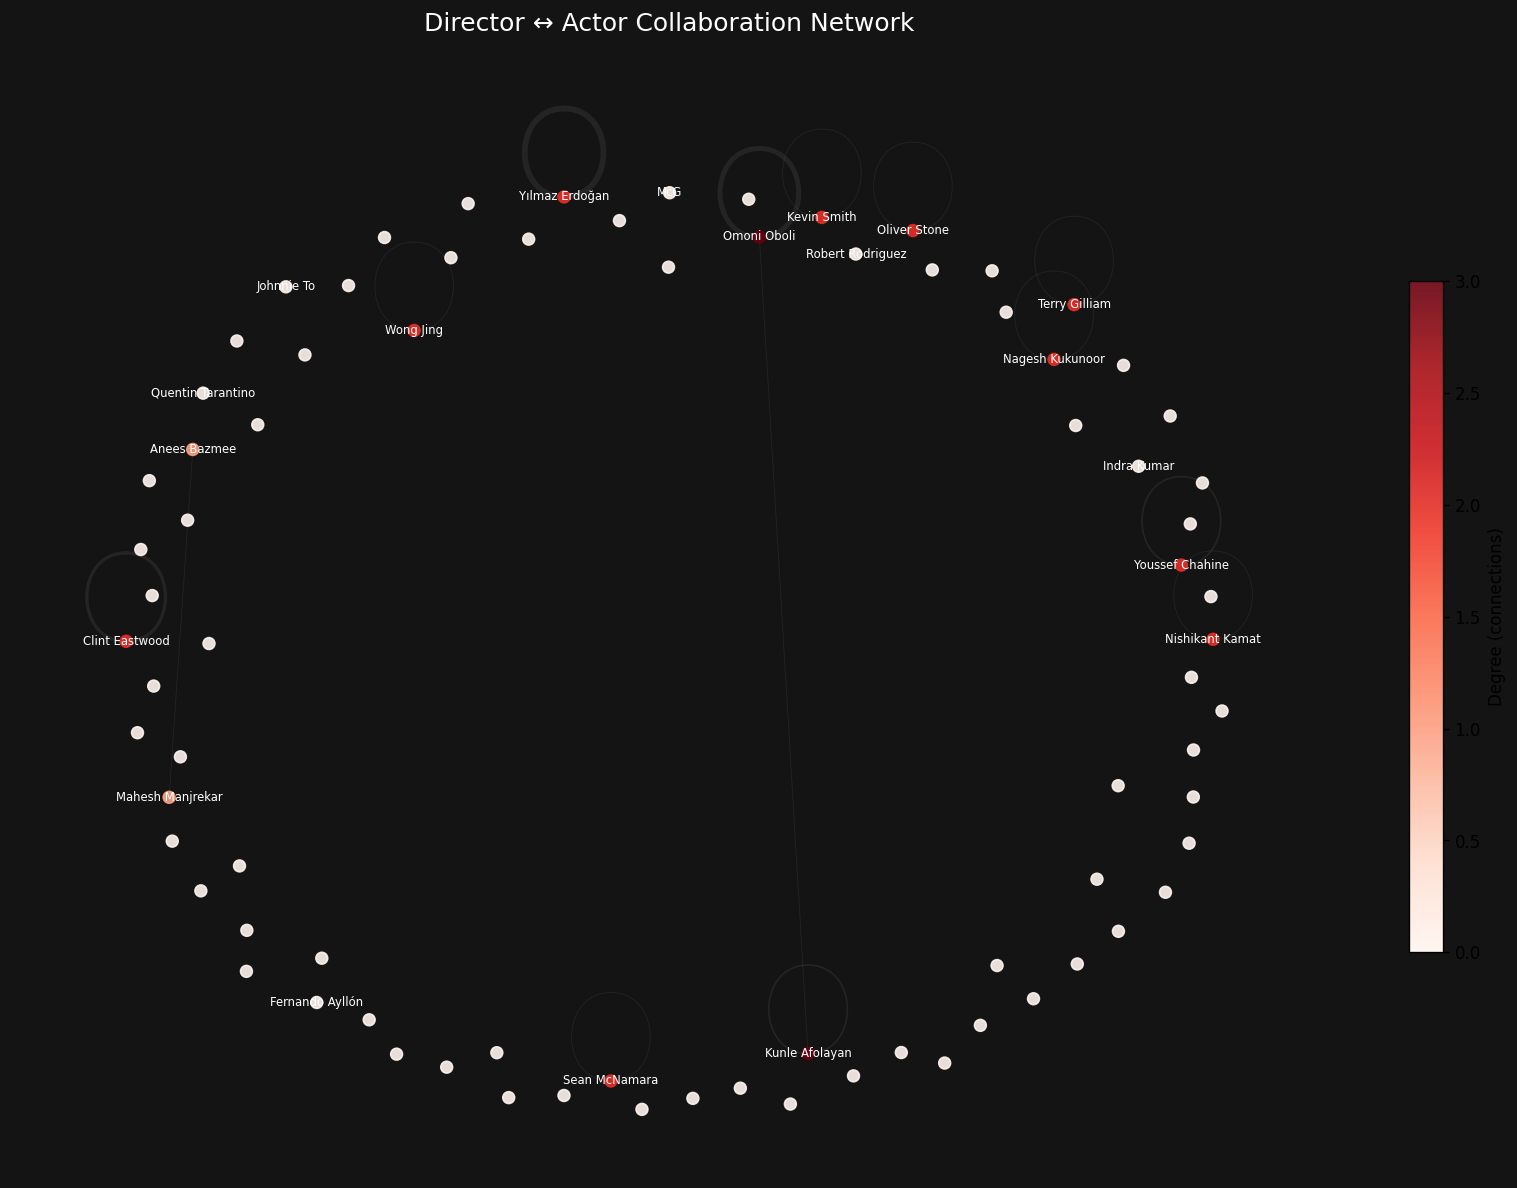

In [7]:
fig = plot_network(G_dir, title='Director ↔ Actor Collaboration Network', max_nodes=80)
plt.show()

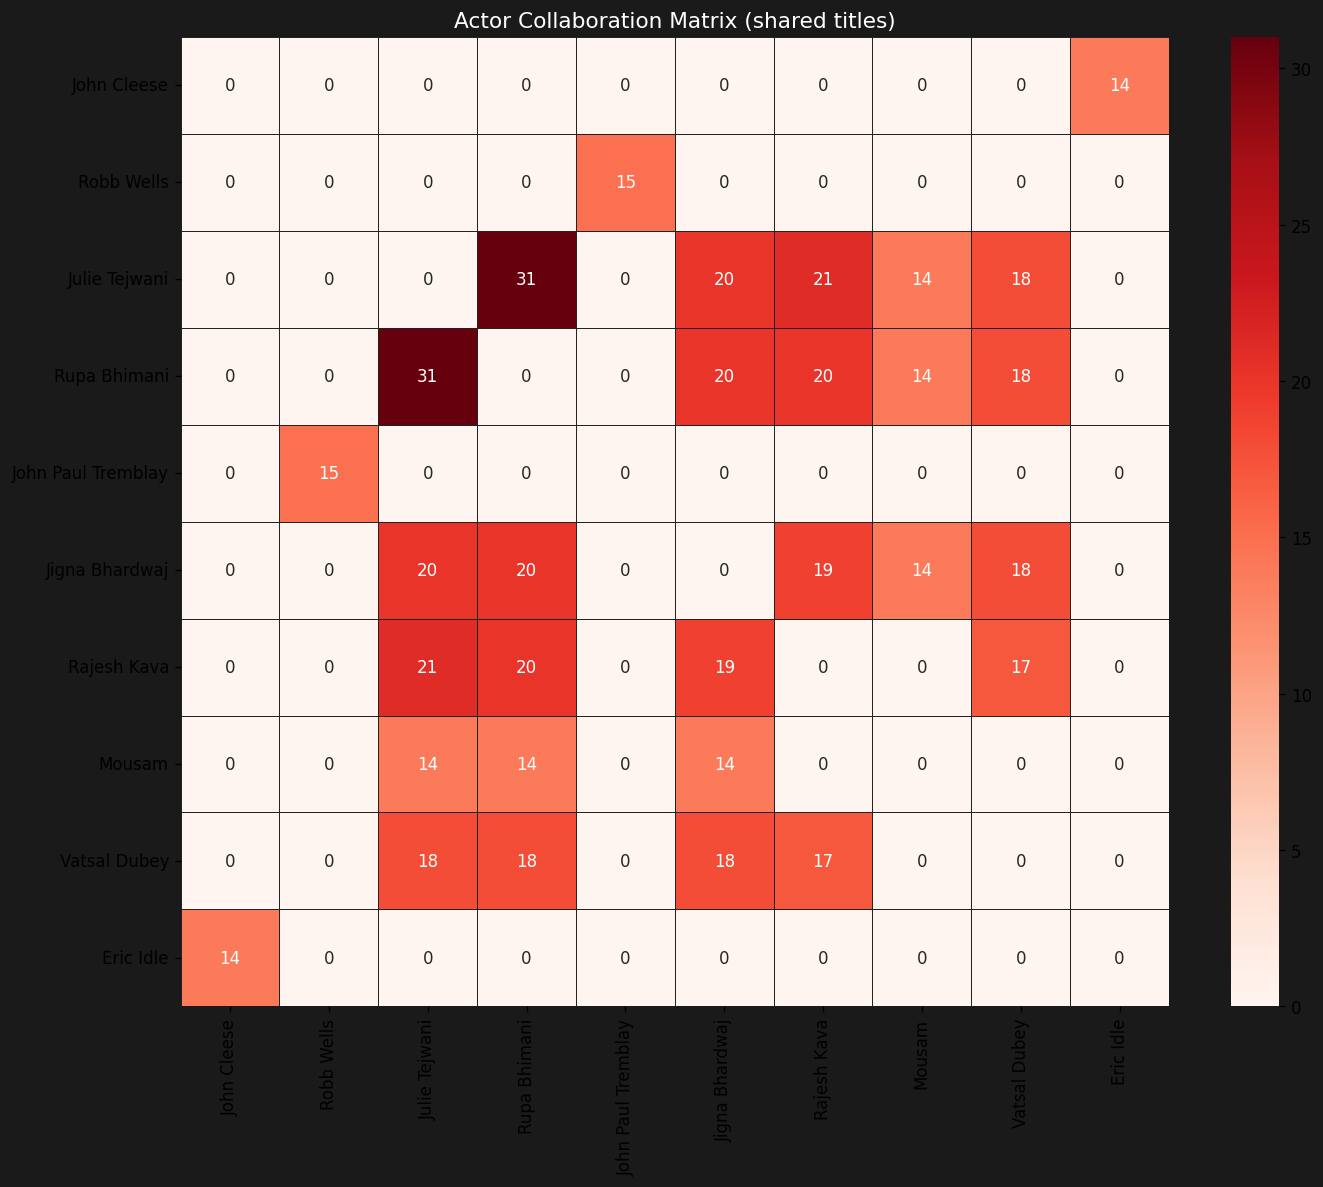

In [8]:
# Collaboration heatmap for top pairs
top_collabs_small = top_collaborations(G, n=15)
fig = plot_collaboration_heatmap(top_collabs_small, n=10)
plt.show()